# Knowledge Distillation — EPT100 Insect Dataset
### EfficientNet-B2 (Teacher) → EfficientNet-B0 + Custom CNN + MobileNetV3(Students)

**Models for comparison:**
1. `Teacher` — EfficientNet-B2, fine-tuned on EPT100
2. `Student-Hard` — EfficientNet-B0, hard labels only
3. `Student-KD` — EfficientNet-B0, Hinton's distillation
4. `CustomCNN-Hard` — Small custom CNN, hard labels only
5. `CustomCNN-KD` — Small custom CNN, Hinton's distillation
6. `MobileNetV3-Hard` — Edge baseline, hard labels only
7. `MobileNetV3-KD` - Edge baseline, Hinton's distillation

**Metrics:** Top-1 Accuracy, Top-5 Accuracy, Loss curves

## 0. Installation and Imports

In [1]:
!pip install -q timm matplotlib seaborn


In [2]:
import os, time, copy, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
  GPU: Tesla T4


## 1. Google Drive
> Expected Drive folder structure:
> ```
> MyDrive/knowledge_distillation_EPT100/
>   Dataset/
>     train_512/  (101/ 102/ ... 200/)
>     val_512/
>     test_512/
> ```
Dataset HAVE TO be in MyDrive folder as .zip file (Dataset.zip).

In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_BASE  = Path('/content/drive/MyDrive/knowledge_distillation_EPT100')
    DRIVE_DATA  = DRIVE_BASE / 'Dataset'
    BASE_DIR    = DRIVE_BASE
else:
    DRIVE_BASE  = None
    DRIVE_DATA  = None
    BASE_DIR    = Path('./artifacts')

# Local Colab filesystem
LOCAL_DATA = Path('/content/EPT100_Dataset')
RUNS_DIR   = BASE_DIR / 'runs'
PLOTS_DIR  = BASE_DIR / 'plots'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base dir : {BASE_DIR}')
print(f'Drive data: {DRIVE_DATA}')
print(f'Local data: {LOCAL_DATA}')
print(f'Runs dir  : {RUNS_DIR}')


Mounted at /content/drive
Base dir : /content/drive/MyDrive/knowledge_distillation_EPT100
Drive data: /content/drive/MyDrive/knowledge_distillation_EPT100/Dataset
Local data: /content/EPT100_Dataset
Runs dir  : /content/drive/MyDrive/knowledge_distillation_EPT100/runs


## 2. Copying the dataset from Drive to local Colab filesystem
> Local `/content/` is much faster than Drive during training.
> This cell is skipped if the dataset is already copied locally.

In [4]:
import os
import time
from pathlib import Path
import shutil

DRIVE_ZIP = Path('/content/drive/MyDrive/Dataset.zip')
# Root extraction point
EXTRACT_ROOT = Path('/content/dataset_512')
# Path to actual data (ZIP contains 'Dataset' folder)
LOCAL_DATA = EXTRACT_ROOT / 'Dataset'

SPLITS = ['train_512', 'val_512', 'test_512']

def _split_ok(local_split_dir):
    if not local_split_dir.exists():
        return False
    class_dirs = [d for d in local_split_dir.iterdir() if d.is_dir()]
    return len(class_dirs) > 0

print('Checking local dataset...')
all_ok = all(_split_ok(LOCAL_DATA / s) for s in SPLITS)

if all_ok:
    print('Dataset is already locally available — skipping copying.')
else:
    print('Copying and unzipping dataset from Drive...')
    if not DRIVE_ZIP.exists():
        raise RuntimeError(f'ZIP archive not found on Drive: {DRIVE_ZIP}')

    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    t0 = time.time()

    local_zip_path = EXTRACT_ROOT / 'dataset.zip'
    shutil.copy(str(DRIVE_ZIP), str(local_zip_path))

    print('Extracting...', end=' ', flush=True)
    os.system(f'unzip -q {local_zip_path} -d {EXTRACT_ROOT}')

    local_zip_path.unlink()
    print(f'finished ({time.time()-t0:.0f}s)')

if not LOCAL_DATA.exists():
    raise FileNotFoundError(f'Folder {LOCAL_DATA} not found after unzip. Check ZIP structure.')

n_classes = len([d for d in (LOCAL_DATA/"train_512").iterdir() if d.is_dir()])
print(f'\nNumber of classes: {n_classes}')
print(f'Train images: {sum(1 for _ in (LOCAL_DATA/"train_512").rglob("*.jpg"))}')
print(f'Val images  : {sum(1 for _ in (LOCAL_DATA/"val_512").rglob("*.jpg"))}')
print(f'Test images : {sum(1 for _ in (LOCAL_DATA/"test_512").rglob("*.jpg"))}')

Checking local dataset...
Copying and unzipping dataset from Drive...
Extracting... finished (26s)

Number of classes: 100
Train images: 8583
Val images  : 3368
Test images : 5152


**Because the validation set contains empthy folders, just delete them: 140, 159, 179 and 181!**

## 3. Hyperparameter Configuration


In [5]:
NUM_CLASSES  = 100
NUM_WORKERS  = 2

IMG_SIZE_TEACHER  = 512
IMG_SIZE_STUDENT  = 224

BATCH_SIZE_TEACHER = 16
BATCH_SIZE_STUDENT = 16

EPOCHS           = 30
LR               = 1e-4
LR_CUSTOM        = 1e-3
WEIGHT_DECAY     = 1e-4

CHECKPOINT_INTERVAL = 1
RESUME_TRAINING     = True

# Hinton KD parameters
TEMPERATURE = 10.0
ALPHA       = 0.7

print(f'Teacher batch: {BATCH_SIZE_TEACHER} @ {IMG_SIZE_TEACHER}px')
print(f'Student batch: {BATCH_SIZE_STUDENT} @ {IMG_SIZE_STUDENT}px')
print(f'Epochs: {EPOCHS} | LR: {LR} | T: {TEMPERATURE} | Alpha: {ALPHA}')

Teacher batch: 16 @ 512px
Student batch: 16 @ 224px
Epochs: 30 | LR: 0.0001 | T: 10.0 | Alpha: 0.7


## 4. Transforms and DataLoaders
> Two separate transform pipelines: 512px for teacher, 224px for students.

In [6]:
import os

# ----- TRANSFORMERS AND DATA LOADING -----
# These values are standard for models pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation is applied ONLY to the training set to increase robustness
shared_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_TEACHER, IMG_SIZE_TEACHER)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation and test use only Resize and Normalization (no random changes)
shared_val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_TEACHER, IMG_SIZE_TEACHER)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Paths to splits
train_path = LOCAL_DATA / 'train_512'
val_path   = LOCAL_DATA / 'val_512'
test_path  = LOCAL_DATA / 'test_512'

# Function to clean hidden system folders
def remove_ipynb_checkpoints(path):
    for root, dirs, files in os.walk(path):
        if '.ipynb_checkpoints' in dirs:
            shutil.rmtree(os.path.join(root, '.ipynb_checkpoints'))
            print(f"Removed .ipynb_checkpoints from: {root}")

remove_ipynb_checkpoints(train_path)
remove_ipynb_checkpoints(val_path)
remove_ipynb_checkpoints(test_path)

# 1. Creating dataset objects - Train first (as it contains all folders)
train_ds = datasets.ImageFolder(train_path, shared_train_tf)

# 2. Loading Val and Test (PyTorch loads them but with WRONG indices if folders are missing)
val_ds   = datasets.ImageFolder(val_path,   shared_val_tf)
test_ds  = datasets.ImageFolder(test_path,  shared_val_tf)

# 3. Defining a function to fix shifted labels
def uskladi_labele(target_ds, reference_ds):
    # Copy reference classes from training set
    target_ds.classes = reference_ds.classes
    target_ds.class_to_idx = reference_ds.class_to_idx

    novi_samples = []
    novi_targets = []

    # Iterate through images and map them to correct indices from the train set
    for putanja, _ in target_ds.samples:
        ime_foldera_klase = os.path.basename(os.path.dirname(putanja))
        tacan_indeks = reference_ds.class_to_idx[ime_foldera_klase]
        novi_samples.append((putanja, tacan_indeks))
        novi_targets.append(tacan_indeks)

    target_ds.samples = novi_samples
    target_ds.targets = novi_targets
    target_ds.imgs = novi_samples

# 4. Apply label synchronization
uskladi_labele(val_ds, train_ds)
uskladi_labele(test_ds, train_ds)

# 5. Create DataLoaders
sync_train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_STUDENT, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
sync_val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE_STUDENT, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
sync_test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE_STUDENT, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'All loaders synchronized on {IMG_SIZE_TEACHER}px base. Labels successfully mapped to the train set.')

Removed .ipynb_checkpoints from: /content/dataset_512/Dataset/val_512
All loaders synchronized on 512px base. Labels successfully mapped to the train set.


## 5. Model Definition

In [7]:
def build_teacher(num_classes=NUM_CLASSES):
    model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=num_classes)
    # Unfreeze only the last blocks: blocks.6, bn2 and classifier
    for name, param in model.named_parameters():
        if not (name.startswith('blocks.6') or name.startswith('bn2') or name.startswith('classifier')):
            param.requires_grad = False
    return model

def build_student_b0(num_classes=NUM_CLASSES):
    return timm.create_model('efficientnet_b0', pretrained=False, num_classes=num_classes)

class TinyCustomCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        def conv_bn_relu(in_ch, out_ch, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU6(inplace=True))
        def dw_sep(in_ch, out_ch, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
                nn.BatchNorm2d(in_ch),
                nn.ReLU6(inplace=True),
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU6(inplace=True))
        self.features = nn.Sequential(
            conv_bn_relu(3, 32, 2),
            dw_sep(32, 64, 2),
            dw_sep(64, 128, 2),
            dw_sep(128, 128, 1),
            dw_sep(128, 256, 2))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(self.dropout(x))

def build_mobilenet_v3(num_classes=NUM_CLASSES):
    return timm.create_model('mobilenetv3_small_100', pretrained=False, num_classes=num_classes)

# Initialize all models
teacher      = build_teacher().to(DEVICE)
student_b0_h = build_student_b0().to(DEVICE)
student_b0_k = build_student_b0().to(DEVICE)
tiny_cnn_hard = TinyCustomCNN().to(DEVICE)
tiny_cnn_kd   = TinyCustomCNN().to(DEVICE)
mobilenet_v3 = build_mobilenet_v3().to(DEVICE)

print('All models initialized.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

All models initialized.


## 6. Loss Functions and Training Loops

In [8]:
def kd_loss(student_logits, teacher_logits, labels,
            temperature=TEMPERATURE, alpha=ALPHA):
    """
    Hinton et al. (2015) Knowledge Distillation Loss.
    L_total = alpha * L_KD(T) + (1 - alpha) * L_CE
    """
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    l_kd = F.kl_div(soft_student, soft_teacher,
                    reduction='batchmean') * (temperature ** 2)
    l_ce = F.cross_entropy(student_logits, labels)
    return alpha * l_kd + (1.0 - alpha) * l_ce


def topk_accuracy(output, target, topk=(1, 5)):
    with torch.no_grad():
        maxk  = max(topk)
        batch = target.size(0)
        _, pred = output.topk(maxk, dim=1, largest=True, sorted=True)
        pred    = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        return [
            (correct[:k].reshape(-1).float().sum() / batch * 100).item()
            for k in topk
        ]

In [9]:
def train_one_epoch(model, loader, optimizer, teacher_model=None, is_teacher_training=False):
    model.train()
    if teacher_model is not None: teacher_model.eval()

    total_loss = top1_sum = top5_sum = batches = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        # Scenario 1: Knowledge Distillation
        if teacher_model is not None:
            images_s = F.interpolate(images, size=(IMG_SIZE_STUDENT, IMG_SIZE_STUDENT),
                                     mode='bilinear', align_corners=False)
            student_logits = model(images_s)
            with torch.no_grad():
                teacher_logits = teacher_model(images)
            loss = kd_loss(student_logits, teacher_logits, labels)
            top1, top5 = topk_accuracy(student_logits, labels)

        # Scenario 2: Teacher Standalone Training (Full 512px)
        elif is_teacher_training:
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            top1, top5 = topk_accuracy(logits, labels)

        # Scenario 3: Student Standalone Training (Downsample to 224px)
        else:
            images_s = F.interpolate(images, size=(IMG_SIZE_STUDENT, IMG_SIZE_STUDENT),
                                     mode='bilinear', align_corners=False)
            logits = model(images_s)
            loss = F.cross_entropy(logits, labels)
            top1, top5 = topk_accuracy(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        top1_sum += top1; top5_sum += top5; batches += 1

    return total_loss/batches, top1_sum/batches, top5_sum/batches

In [10]:
def _slugify(text):
    return ''.join(
        c.lower() if c.isalnum() else '_' for c in text
    ).strip('_')

def _get_run_dirs(name):
    safe = _slugify(name)
    rd   = RUNS_DIR / safe
    dirs = {
        'run_dir':        rd,
        'checkpoint_dir': rd / 'checkpoints',
        'model_dir':      rd / 'models',
        'safe_name':      safe,
    }
    for d in dirs.values():
        if isinstance(d, Path):
            d.mkdir(parents=True, exist_ok=True)
    return dirs

def _ckpt_payload(epoch, model, optimizer, scheduler, history, best_val_loss, best_weights, name, epochs_no_improve=0):
    return {
        'epoch':               epoch,
        'model_state_dict':    model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'scheduler_state_dict':scheduler.state_dict(),
        'history':             history,
        'best_val_loss':       best_val_loss,
        'best_weights':        best_weights,
        'name':                name,
        'epochs_no_improve':   epochs_no_improve,
    }

def _opt_matches(optimizer, saved):
    cur_g = optimizer.param_groups
    sav_g = saved.get('param_groups', [])
    if len(cur_g) != len(sav_g):
        return False
    return all(
        len(cg['params']) == len(sg['params'])
        for cg, sg in zip(cur_g, sav_g)
    )

@torch.no_grad()
def evaluate(model, loader, img_size=IMG_SIZE_STUDENT):
    model.eval()
    total_loss = top1_sum = top5_sum = batches = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        images_eval = F.interpolate(images, size=(img_size, img_size), mode='bilinear', align_corners=False)
        logits = model(images_eval)
        loss   = F.cross_entropy(logits, labels)
        top1, top5 = topk_accuracy(logits, labels)
        total_loss += loss.item()
        top1_sum += top1; top5_sum += top5; batches += 1
    return total_loss/batches, top1_sum/batches, top5_sum/batches

def train_model(model, name, train_loader, val_loader, epochs=EPOCHS, lr=LR, teacher_model=None, resume=RESUME_TRAINING, early_stopping_patience=15, min_delta=0.001):
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    paths = _get_run_dirs(name)
    history = {'train_loss':[], 'val_loss':[], 'train_top1':[], 'val_top1':[], 'train_top5':[], 'val_top5':[]}

    best_val_loss = float('inf')
    best_weights = None
    start_epoch = 1
    epochs_no_improve = 0
    resume_path = paths['checkpoint_dir'] / 'resume_state.pt'
    best_path = paths['checkpoint_dir'] / 'best.pt'
    final_path = paths['model_dir'] / 'final_best.pt'

    if resume and resume_path.exists():
        ckpt = torch.load(resume_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        if _opt_matches(optimizer, ckpt.get('optimizer_state_dict', {})): optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if 'scheduler_state_dict' in ckpt: scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        history = ckpt.get('history', history)

        best_weights = ckpt.get('best_weights', ckpt['model_state_dict'])
        start_epoch = ckpt.get('epoch', 0) + 1

        # LOADING COUNTERS AND LOSS
        epochs_no_improve = ckpt.get('epochs_no_improve', 0)
        if history.get('val_loss'):
            best_val_loss = min(history['val_loss'])
        else:
            best_val_loss = ckpt.get('best_val_loss', float('inf'))

    if best_weights is None: best_weights = copy.deepcopy(model.state_dict())

    is_teacher_run = "teacher" in name.lower()
    eval_size = IMG_SIZE_TEACHER if is_teacher_run else IMG_SIZE_STUDENT
    print(f'\nTraining: {name} | Mode: {"KD" if teacher_model else "Hard"} | Resolution: {eval_size}px')

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss, tr1, tr5 = train_one_epoch(model, train_loader, optimizer, teacher_model=teacher_model, is_teacher_training=is_teacher_run)
        vl_loss, vl1, vl5 = evaluate(model, val_loader, img_size=eval_size)
        scheduler.step()

        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_top1'].append(tr1); history['val_top1'].append(vl1)
        history['train_top5'].append(tr5); history['val_top5'].append(vl5)

        improved = vl_loss < (best_val_loss - min_delta)

        if improved:
            best_val_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            payload = _ckpt_payload(epoch, model, optimizer, scheduler, history, best_val_loss, best_weights, name, epochs_no_improve=0)
            torch.save(payload, best_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f'  Ep {epoch:2d} | Loss: {tr_loss:.3f}/{vl_loss:.3f} | Top-1: {tr1:.1f}%/{vl1:.1f}% | Top-5: {tr5:.1f}%/{vl5:.1f}% | {time.time()-t0:.0f}s' + (' *' if improved else ''))

        # SAVE CURRENT STATE TO RESUME_PATH
        current_payload = _ckpt_payload(epoch, model, optimizer, scheduler, history, best_val_loss, best_weights, name, epochs_no_improve=epochs_no_improve)
        torch.save(current_payload, resume_path)

        if epochs_no_improve >= early_stopping_patience:
            print(f'Early stopping triggered at epoch {epoch} based on val_loss.')
            break

    model.load_state_dict(best_weights)
    torch.save({'model_state_dict': model.state_dict(), 'best_val_loss': best_val_loss, 'history': history, 'name': name}, final_path)
    print(f'>>> Finished. Best Val Loss: {best_val_loss:.4f} | Saved to: final_best.pt')
    return history

#### Run next cell only to check if the train/val/test lables are now mapped well after deleting the folders in val_512 folder.

In [11]:
def check_full_structure(dataset, set_name):
    mismatch_samples_imgs = 0
    mismatch_samples_targets = 0

    # Check the entire set in one loop
    for i in range(len(dataset)):
        p1, idx_s = dataset.samples[i]
        p2, idx_im = dataset.imgs[i]
        idx_t = dataset.targets[i]

        if idx_s != idx_im:
            mismatch_samples_imgs += 1
        if idx_s != idx_t:
            mismatch_samples_targets += 1

    print(f"--- Report for {set_name} ---")
    print(f"Total images: {len(dataset)}")
    print(f"Mismatches samples vs imgs: {mismatch_samples_imgs}")
    print(f"Mismatches samples vs targets: {mismatch_samples_targets}\n")

# Run check for validation and test
check_full_structure(val_ds, "Validation Set")
check_full_structure(test_ds, "Test Set")

--- Report for Validation Set ---
Total images: 3368
Mismatches samples vs imgs: 0
Mismatches samples vs targets: 0

--- Report for Test Set ---
Total images: 5152
Mismatches samples vs imgs: 0
Mismatches samples vs targets: 0



## 7. Teacher Training
> EfficientNet-B2 with ImageNet weights — fine-tuning only the last blocks.
> Goal: achieve ~95%+ on EPT100 (professor achieved 98.56% with Keras version).

> Training of all the models is saved directly to Drive. To load the last saved checkpoint keep `resume = True`, to start again from the beggining set `resume = False`.

> Change the number of epochs and early stopping as it suits you. I usually train 10 per 10 epochs in case I run out of the Colab credits, because it can delete your unsaved progress in the middle of the training.

> To train a new model so it is saved in Drive, just copy+paste the code cell for the model that already exists and change the name of the model, since they differ by name. Take in care to use *Knowledge Distillation*, *Teacher*, or *10* in the names of the models, because of the architecture of the code.

In [ ]:
TEACHER_NAME = 'Teacher (EfficientNet-B2)'

print('Fine-tuning teacher...')
history_teacher = train_model(
    teacher,
    name=TEACHER_NAME,
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=30,
    lr=1e-4,
    early_stopping_patience=5,
    min_delta=0.1,
    resume=False,
)

# Freeze the entire teacher
for param in teacher.parameters():
    param.requires_grad = False
teacher.eval()
print('Teacher frozen — ready for distillation.')

Fine-tuning teacher...

Training: Teacher (EfficientNet-B2) | Mode: Hard | Resolution: 512px
  Ep  1 | Loss: 2.078/0.696 | Top-1: 59.0%/83.9% | 207s *
  Ep  2 | Loss: 0.582/0.280 | Top-1: 88.4%/93.2% | 197s *
  Ep  3 | Loss: 0.274/0.169 | Top-1: 94.5%/95.7% | 204s *
  Ep  4 | Loss: 0.172/0.112 | Top-1: 96.8%/96.7% | 201s *
  Ep  5 | Loss: 0.124/0.091 | Top-1: 97.2%/97.5% | 202s *
  Ep  6 | Loss: 0.093/0.078 | Top-1: 97.9%/97.7% | 208s *
  Ep  7 | Loss: 0.073/0.078 | Top-1: 98.4%/97.8% | 202s
  Ep  8 | Loss: 0.061/0.077 | Top-1: 98.7%/97.6% | 199s
  Ep  9 | Loss: 0.052/0.063 | Top-1: 98.8%/97.9% | 202s *
  Ep 10 | Loss: 0.042/0.060 | Top-1: 99.1%/98.1% | 203s *
  Ep 11 | Loss: 0.035/0.059 | Top-1: 99.2%/98.0% | 212s
  Ep 12 | Loss: 0.037/0.050 | Top-1: 99.1%/98.3% | 210s *
  Ep 13 | Loss: 0.026/0.065 | Top-1: 99.5%/97.8% | 210s
  Ep 14 | Loss: 0.023/0.049 | Top-1: 99.5%/98.4% | 209s
  Ep 15 | Loss: 0.024/0.062 | Top-1: 99.5%/98.3% | 206s
  Ep 16 | Loss: 0.023/0.064 | Top-1: 99.4%/98.1% 

## 8. Trening — EfficientNet-B0 (Hard Labels)

In [ ]:
history_b0_hard = train_model(
    student_b0_h,
    name='Student B0 — Hard Labels',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=50,
    lr=LR,
    teacher_model=None, # Koristi hard labele
    early_stopping_patience=15,
    resume=True,
)


Training: Student B0 — Hard Labels | Mode: Hard | Resolution: 224px
  Ep 48 | Loss: 0.165/0.355 | Top-1: 94.5%/89.5% | Top-5: 99.9%/99.3% | 193s
  Ep 49 | Loss: 0.161/0.327 | Top-1: 94.5%/90.9% | Top-5: 100.0%/99.5% | 175s
  Ep 50 | Loss: 0.156/0.351 | Top-1: 94.8%/89.9% | Top-5: 100.0%/99.4% | 176s
>>> Finished. Best Val Loss: 0.2769 | Saved to: final_best.pt


## 8.1. Trening — EfficientNet-B0 (Knowledge Distillation)

In [ ]:
print('Starting Student B0 Knowledge Distillation...')
# Updated parameters: epochs=60, patience=15, min_delta=0.001
history_b0_kd = train_model(
    student_b0_k,
    name='Student B0 — Knowledge Distillation',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=130,
    lr=LR,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True,
)

Starting Student B0 Knowledge Distillation...

Training: Student B0 — Knowledge Distillation | Mode: KD | Resolution: 224px
  Ep 101 | Loss: 0.392/0.641 | Top-1: 99.3%/93.6% | Top-5: 100.0%/98.9% | 209s
  Ep 102 | Loss: 0.390/0.627 | Top-1: 99.4%/94.0% | Top-5: 100.0%/98.8% | 199s
  Ep 103 | Loss: 0.391/0.649 | Top-1: 99.4%/93.4% | Top-5: 100.0%/98.7% | 201s
  Ep 104 | Loss: 0.393/0.675 | Top-1: 99.1%/92.7% | Top-5: 100.0%/98.8% | 204s
  Ep 105 | Loss: 0.393/0.676 | Top-1: 99.2%/93.0% | Top-5: 100.0%/98.8% | 214s
  Ep 106 | Loss: 0.394/0.680 | Top-1: 99.2%/93.3% | Top-5: 100.0%/98.4% | 208s
  Ep 107 | Loss: 0.393/0.665 | Top-1: 99.3%/93.3% | Top-5: 100.0%/98.9% | 200s
  Ep 108 | Loss: 0.394/0.662 | Top-1: 99.1%/92.6% | Top-5: 100.0%/98.7% | 206s
  Ep 109 | Loss: 0.394/0.686 | Top-1: 99.2%/92.5% | Top-5: 100.0%/98.7% | 203s
  Ep 110 | Loss: 0.394/0.662 | Top-1: 99.3%/93.5% | Top-5: 100.0%/98.6% | 202s
  Ep 111 | Loss: 0.396/0.651 | Top-1: 99.2%/93.3% | Top-5: 100.0%/98.8% | 207s
  Ep 11

## 8.1.1 TEMPERATURE = 10

In [ ]:
print('Starting Student B0 Knowledge Distillation...')
# Updated parameters: epochs=60, patience=15, min_delta=0.001
history_b0_kd = train_model(
    student_b0_k,
    name='Student B0 — Knowledge Distillation T10',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=115,
    lr=LR,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True,
)

Starting Student B0 Knowledge Distillation...

Training: Student B0 — Knowledge Distillation T10 | Mode: KD | Resolution: 224px
  Ep 111 | Loss: 0.320/0.481 | Top-1: 98.3%/92.8% | Top-5: 100.0%/99.0% | 212s


## 9. Trening — Tiny Custom CNN (Hard Labels)

In [ ]:
history_tiny_hard = train_model(
    tiny_cnn_hard,
    name='Tiny CNN — Hard Labels',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=60,
    lr=LR_CUSTOM,
    teacher_model=None,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True
)


Training: Tiny CNN — Hard Labels | Mode: Hard | Resolution: 224px
  Ep 31 | Loss: 0.433/0.388 | Top-1: 87.1%/89.2% | Top-5: 99.3%/99.1% | 161s
  Ep 32 | Loss: 0.434/0.372 | Top-1: 87.4%/89.9% | Top-5: 99.2%/99.2% | 160s
  Ep 33 | Loss: 0.435/0.365 | Top-1: 87.1%/90.0% | Top-5: 99.1%/99.1% | 167s *
  Ep 34 | Loss: 0.443/0.373 | Top-1: 86.8%/89.5% | Top-5: 99.0%/99.1% | 153s
  Ep 35 | Loss: 0.430/0.367 | Top-1: 87.3%/89.7% | Top-5: 99.2%/99.1% | 153s
  Ep 36 | Loss: 0.429/0.362 | Top-1: 87.9%/89.9% | Top-5: 99.1%/99.2% | 163s *
  Ep 37 | Loss: 0.432/0.365 | Top-1: 87.1%/90.1% | Top-5: 99.0%/99.1% | 168s
  Ep 38 | Loss: 0.432/0.375 | Top-1: 87.3%/89.8% | Top-5: 99.1%/99.0% | 168s
  Ep 39 | Loss: 0.437/0.370 | Top-1: 86.9%/90.0% | Top-5: 99.2%/99.1% | 162s
  Ep 40 | Loss: 0.433/0.370 | Top-1: 87.4%/89.1% | Top-5: 99.1%/99.1% | 163s
  Ep 41 | Loss: 0.437/0.377 | Top-1: 86.9%/89.2% | Top-5: 99.1%/99.2% | 167s
  Ep 42 | Loss: 0.449/0.394 | Top-1: 86.5%/88.7% | Top-5: 99.0%/99.1% | 160s
  Ep 

## 9.1 Trening — Tiny Custom CNN (Knowledge Distillation)

In [ ]:
history_tiny_kd = train_model(
    tiny_cnn_kd,
    name='Tiny CNN — Knowledge Distillation',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=75,
    lr=LR_CUSTOM,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True
)


Training: Tiny CNN — Knowledge Distillation | Mode: KD | Resolution: 224px
  Ep 71 | Loss: 0.634/0.903 | Top-1: 87.5%/90.0% | Top-5: 98.6%/98.8% | 176s
  Ep 72 | Loss: 0.632/0.922 | Top-1: 88.0%/90.0% | Top-5: 98.6%/98.9% | 178s
  Ep 73 | Loss: 0.635/0.952 | Top-1: 87.8%/89.5% | Top-5: 98.4%/98.7% | 179s
  Ep 74 | Loss: 0.633/0.939 | Top-1: 88.1%/90.0% | Top-5: 98.5%/98.5% | 181s
Early stopping triggered at epoch 74 based on val_loss.
>>> Finished. Best Val Loss: 0.8804 | Saved to: final_best.pt


## 9.1.1 TEMPERATURE = 10

In [ ]:
history_tiny_kd = train_model(
    tiny_cnn_kd,
    name='Tiny CNN — Knowledge Distillation 10',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=100,
    lr=LR_CUSTOM,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True
)

There is no output because it is ran from the different device and not saved (the model is saved in Drive).

## 10. Trening — MobileNetV3-Small (Edge Baseline)

In [ ]:
history_mobile = train_model(
    mobilenet_v3,
    name='MobileNetV3-Small — Edge Baseline',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=110,
    lr=LR,
    teacher_model=None,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True,
)


Training: MobileNetV3-Small — Edge Baseline | Mode: Hard | Resolution: 224px
  Ep 101 | Loss: 0.245/0.405 | Top-1: 91.6%/87.4% | Top-5: 99.9%/99.2% | 171s
  Ep 102 | Loss: 0.246/0.414 | Top-1: 91.3%/87.6% | Top-5: 99.9%/99.2% | 170s
  Ep 103 | Loss: 0.244/0.392 | Top-1: 91.1%/88.5% | Top-5: 99.9%/99.3% | 175s
  Ep 104 | Loss: 0.252/0.402 | Top-1: 91.0%/87.9% | Top-5: 99.8%/99.3% | 172s
  Ep 105 | Loss: 0.269/0.444 | Top-1: 90.6%/87.4% | Top-5: 99.8%/99.2% | 169s
  Ep 106 | Loss: 0.256/0.400 | Top-1: 90.7%/88.4% | Top-5: 99.8%/99.2% | 171s
Early stopping triggered at epoch 106 based on val_loss.
>>> Finished. Best Val Loss: 0.3571 | Saved to: final_best.pt


## 10.1. Trening — MobileNetV3-Small (Knowledge Distillation)
> Hinton's KD applied to the MobileNetV3 edge baseline.

In [ ]:
history_mobile_kd = train_model(
    mobilenet_v3_kd := build_mobilenet_v3().to(DEVICE),
    name='MobileNetV3-Small — Knowledge Distillation',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=110,
    lr=LR,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True,
)


Training: MobileNetV3-Small — Knowledge Distillation | Mode: KD | Resolution: 224px
  Ep 101 | Loss: 0.512/0.822 | Top-1: 89.2%/88.6% | Top-5: 99.4%/98.6% | 192s
  Ep 102 | Loss: 0.504/0.859 | Top-1: 90.1%/87.2% | Top-5: 99.4%/98.4% | 194s
  Ep 103 | Loss: 0.500/0.897 | Top-1: 90.3%/86.5% | Top-5: 99.5%/98.3% | 192s
  Ep 104 | Loss: 0.494/0.786 | Top-1: 90.5%/89.5% | Top-5: 99.6%/98.7% | 190s
  Ep 105 | Loss: 0.488/0.791 | Top-1: 91.2%/88.3% | Top-5: 99.6%/98.9% | 191s
Early stopping triggered at epoch 105 based on val_loss.
>>> Finished. Best Val Loss: 0.7645 | Saved to: final_best.pt


## 10.1.1 TEMPERATURE = 10

In [ ]:
history_mobile_kd = train_model(
    mobilenet_v3_kd := build_mobilenet_v3().to(DEVICE),
    name='MobileNetV3-Small — Knowledge Distillation10',
    train_loader=sync_train_loader,
    val_loader=sync_val_loader,
    epochs=120,
    lr=LR,
    teacher_model=teacher,
    early_stopping_patience=15,
    min_delta=0.001,
    resume=True,
)


Training: MobileNetV3-Small — Knowledge Distillation10 | Mode: KD | Resolution: 224px
  Ep 86 | Loss: 0.457/0.679 | Top-1: 86.9%/87.1% | Top-5: 99.2%/98.6% | 187s *
  Ep 87 | Loss: 0.451/0.687 | Top-1: 87.5%/86.2% | Top-5: 99.5%/98.5% | 189s
  Ep 88 | Loss: 0.444/0.679 | Top-1: 88.5%/87.1% | Top-5: 99.4%/98.5% | 187s
  Ep 89 | Loss: 0.438/0.687 | Top-1: 89.2%/86.6% | Top-5: 99.5%/98.2% | 186s
  Ep 90 | Loss: 0.434/0.666 | Top-1: 89.0%/87.5% | Top-5: 99.4%/98.4% | 187s *
  Ep 91 | Loss: 0.430/0.647 | Top-1: 89.6%/87.9% | Top-5: 99.4%/98.4% | 190s *
  Ep 92 | Loss: 0.426/0.628 | Top-1: 89.8%/87.9% | Top-5: 99.6%/98.6% | 188s *
  Ep 93 | Loss: 0.421/0.614 | Top-1: 90.1%/88.2% | Top-5: 99.6%/98.7% | 189s *
  Ep 94 | Loss: 0.415/0.627 | Top-1: 90.8%/88.1% | Top-5: 99.7%/98.6% | 188s
  Ep 95 | Loss: 0.413/0.622 | Top-1: 90.7%/88.4% | Top-5: 99.7%/98.7% | 187s
  Ep 96 | Loss: 0.411/0.595 | Top-1: 91.0%/88.7% | Top-5: 99.6%/98.5% | 188s *
  Ep 97 | Loss: 0.410/0.635 | Top-1: 91.6%/88.0% | Top

# 11. EVALUATION

This cell in not required to run.

In [ ]:
# 1. Using the already defined and synchronized test_loader from section 4
# sync_test_loader already has correct transforms and mapped labels

# 2. Path to the final Teacher model
teacher_safe_name = _slugify('Teacher (EfficientNet-B2)')
teacher_ckpt_path = RUNS_DIR / teacher_safe_name / 'models' / 'final_best.pt'

if teacher_ckpt_path.exists():
    # 3. Load weights
    print(f"Loading weights from: {teacher_ckpt_path}")
    ckpt = torch.load(teacher_ckpt_path, map_location=DEVICE)
    teacher.load_state_dict(ckpt['model_state_dict'])
    teacher.eval()

    # 4. Run evaluation on test set (using IMG_SIZE_TEACHER i.e. 512px)
    print(f"Evaluating Teacher on test set ({IMG_SIZE_TEACHER}px)...\n")
    test_loss, test_top1, test_top5 = evaluate(teacher, sync_test_loader, img_size=IMG_SIZE_TEACHER)

    print(f"[TEST RESULTS — TEACHER]")
    print(f"Loss: {test_loss:.4f} | Top-1: {test_top1:.2f}% | Top-5: {test_top5:.2f}%")
else:
    print(f"ERROR: Checkpoint not found at {teacher_ckpt_path}")

Loading weights from: /content/drive/MyDrive/knowledge_distillation_EPT100/runs/teacher__efficientnet_b2/models/final_best.pt
Evaluating Teacher on test set (512px)...

[TEST RESULTS — TEACHER]
Loss: 0.0609 | Top-1: 98.43% | Top-5: 99.92%


## 11.1. Evaluation and comparison of all models


In [13]:
# Re-initialization (safe after restart)
teacher        = build_teacher().to(DEVICE)
student_b0_h   = build_student_b0().to(DEVICE)
student_b0_k   = build_student_b0().to(DEVICE)
student_b0_k10 = build_student_b0().to(DEVICE)
tiny_cnn_hard  = TinyCustomCNN().to(DEVICE)
tiny_cnn_kd    = TinyCustomCNN().to(DEVICE)
tiny_cnn_kd10  = TinyCustomCNN().to(DEVICE)
mobilenet_v3   = build_mobilenet_v3().to(DEVICE)
mobilenet_v3_k = build_mobilenet_v3().to(DEVICE)
mobilenet_v3_k10= build_mobilenet_v3().to(DEVICE)

# Model Registry - including T=10 models
MODEL_REGISTRY = [
    ('Teacher (EfficientNet-B2)',           teacher,      sync_test_loader),
    ('Student B0 — Hard Labels',            student_b0_h, sync_test_loader),
    ('Student B0 — Knowledge Distillation', student_b0_k, sync_test_loader),
    ('Student B0 — Knowledge Distillation T10', student_b0_k10, sync_test_loader),
    ('Tiny CNN — Hard Labels',              tiny_cnn_hard,sync_test_loader),
    ('Tiny CNN — Knowledge Distillation',   tiny_cnn_kd,  sync_test_loader),
    ('Tiny CNN — Knowledge Distillation 10', tiny_cnn_kd10, sync_test_loader),
    ('MobileNetV3-Small — Edge Baseline',   mobilenet_v3, sync_test_loader),
    ('MobileNetV3-Small — Knowledge Distillation', mobilenet_v3_k, sync_test_loader),
    ('MobileNetV3-Small — Knowledge Distillation10', mobilenet_v3_k10, sync_test_loader),
]

def load_best_weights(model, name):
    safe = _slugify(name)
    path = RUNS_DIR / safe / 'models' / 'final_best.pt'
    if path.exists():
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f'✅ Loaded: {name}')
    else:
        print(f'❌ Not found: {name} (Checked path: {path})')

print('Loading weights...')
for name, model, _ in MODEL_REGISTRY:
    load_best_weights(model, name)

# Freeze teacher
for param in teacher.parameters():
    param.requires_grad = False
teacher.eval()

# --- SAVING/LOADING EVALUATION RESULTS ---
RESULTS_PATH = BASE_DIR / 'evaluation_results.pt'
results = {}

if RESULTS_PATH.exists():
    print(f'\n📂 Loading existing evaluation results from Drive...')
    results = torch.load(RESULTS_PATH)
else:
    print(f'\n' + "="*72)
    print('  RUNNING FINAL EVALUATION ON TEST SET — EPT100')
    print("="*72)
    print(f'  {"Model":<45} {"Top-1":>7} {"Top-5":>7} {"Params":>9}')
    print(f'  {"-"*68}')

    for name, model, test_loader in MODEL_REGISTRY:
        is_teacher = "teacher" in name.lower()
        eval_size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT
        loss, top1, top5 = evaluate(model, test_loader, img_size=eval_size)
        params = sum(p.numel() for p in model.parameters()) / 1e6
        results[name] = {'top1': top1, 'top5': top5, 'loss': loss, 'params_M': params}
        print(f'  {name:<45} {top1:>6.2f}% {top5:>6.2f}% {params:>7.1f}M')

    # Save to Drive
    torch.save(results, RESULTS_PATH)
    print(f'\n✅ Evaluation results saved to: {RESULTS_PATH}')

print(f'{"="*72}')

def kd_delta(kd_name, hard_name):
    if kd_name in results and hard_name in results:
        d1 = results[kd_name]['top1'] - results[hard_name]['top1']
        suffix = "(T10)" if "10" in kd_name else ""
        print(f'  KD improvement [{kd_name.split("—")[0].strip()} {suffix}]: Top-1 {d1:+.2f}%')

print() # Comparison of improvements
kd_delta('Student B0 — Knowledge Distillation', 'Student B0 — Hard Labels')
kd_delta('Student B0 — Knowledge Distillation T10', 'Student B0 — Hard Labels')
kd_delta('Tiny CNN — Knowledge Distillation',   'Tiny CNN — Hard Labels')
kd_delta('Tiny CNN — Knowledge Distillation 10', 'Tiny CNN — Hard Labels')
kd_delta('MobileNetV3-Small — Knowledge Distillation', 'MobileNetV3-Small — Edge Baseline')
kd_delta('MobileNetV3-Small — Knowledge Distillation10', 'MobileNetV3-Small — Edge Baseline')

Loading weights...
✅ Loaded: Teacher (EfficientNet-B2)
✅ Loaded: Student B0 — Hard Labels
✅ Loaded: Student B0 — Knowledge Distillation
✅ Loaded: Student B0 — Knowledge Distillation T10
✅ Loaded: Tiny CNN — Hard Labels
✅ Loaded: Tiny CNN — Knowledge Distillation
✅ Loaded: Tiny CNN — Knowledge Distillation 10
✅ Loaded: MobileNetV3-Small — Edge Baseline
✅ Loaded: MobileNetV3-Small — Knowledge Distillation
✅ Loaded: MobileNetV3-Small — Knowledge Distillation10

  RUNNING FINAL EVALUATION ON TEST SET — EPT100
  Model                                           Top-1   Top-5    Params
  --------------------------------------------------------------------
  Teacher (EfficientNet-B2)                      98.43%  99.92%     7.8M
  Student B0 — Hard Labels                       91.01%  99.53%     4.1M
  Student B0 — Knowledge Distillation            93.21%  98.97%     4.1M
  Student B0 — Knowledge Distillation T10        93.32%  98.89%     4.1M
  Tiny CNN — Hard Labels                         89.

In [14]:
def count_misclassified(model, loader, img_size=IMG_SIZE_STUDENT):
    model.eval()
    misclassified = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            images_eval = F.interpolate(images, size=(img_size, img_size), mode='bilinear', align_corners=False)
            logits = model(images_eval)
            preds = torch.argmax(logits, dim=1)
            misclassified += (preds != labels).sum().item()
            total += labels.size(0)
    return misclassified, total

print(f'\n{"="*60}')
print(f'  MISCLASSIFICATION COUNT ON TEST SET (n=5152)')
print(f'{"="*60}')
print(f'  {"Model":<45} {"Errors":>7} / {"Total":>6}')
print(f'  {"-"*56}')

for name, model, loader in MODEL_REGISTRY:
    is_teacher = "teacher" in name.lower()
    eval_size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT

    errors, total = count_misclassified(model, loader, img_size=eval_size)
    print(f'  {name:<45} {errors:>7} / {total:>6}')

print(f'{"="*60}')


  MISCLASSIFICATION COUNT ON TEST SET (n=5152)
  Model                                          Errors /  Total
  --------------------------------------------------------
  Teacher (EfficientNet-B2)                          81 /   5152
  Student B0 — Hard Labels                          463 /   5152
  Student B0 — Knowledge Distillation               350 /   5152
  Student B0 — Knowledge Distillation T10           344 /   5152
  Tiny CNN — Hard Labels                            562 /   5152
  Tiny CNN — Knowledge Distillation                 570 /   5152
  Tiny CNN — Knowledge Distillation 10              444 /   5152
  MobileNetV3-Small — Edge Baseline                 638 /   5152
  MobileNetV3-Small — Knowledge Distillation        600 /   5152
  MobileNetV3-Small — Knowledge Distillation10      610 /   5152


In [15]:
import pandas as pd
import numpy as np

def get_error_indices(model, loader, img_size=IMG_SIZE_STUDENT):
    model.eval()
    error_indices = set()
    current_idx = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            images_eval = F.interpolate(images, size=(img_size, img_size), mode='bilinear', align_corners=False)
            logits = model(images_eval)
            preds = torch.argmax(logits, dim=1)

            # Identify offset within batch
            mismatches = (preds != labels).cpu().numpy()
            for i, is_error in enumerate(mismatches):
                if is_error:
                    error_indices.add(current_idx + i)
            current_idx += labels.size(0)
    return error_indices

# Collecting sets of error indices for each model
model_errors = {}
for name, model, loader in MODEL_REGISTRY:
    is_teacher = "teacher" in name.lower()
    eval_size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT
    print(f"Analyzing errors for: {name}...")
    model_errors[name] = get_error_indices(model, loader, img_size=eval_size)

# Create Intersection Table
names = [n for n, _, _ in MODEL_REGISTRY]
overlap_matrix = np.zeros((len(names), len(names)), dtype=int)

for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        # Number of common elements in error sets
        overlap_matrix[i, j] = len(model_errors[name_i].intersection(model_errors[name_j]))

# Display results using Pandas
df_overlap = pd.DataFrame(overlap_matrix, index=names, columns=names)

print(f'\n{"="*80}')
print('  COMMON ERRORS TABLE (Number of images both models misclassified)')
print(f'{"="*80}')
display(df_overlap)

# Extra stats: Images missed by ALL models
common_to_all = set.intersection(*model_errors.values())
print(f'\nTotal images that NO model managed to predict correctly: {len(common_to_all)}')

Analyzing errors for: Teacher (EfficientNet-B2)...
Analyzing errors for: Student B0 — Hard Labels...
Analyzing errors for: Student B0 — Knowledge Distillation...
Analyzing errors for: Student B0 — Knowledge Distillation T10...
Analyzing errors for: Tiny CNN — Hard Labels...
Analyzing errors for: Tiny CNN — Knowledge Distillation...
Analyzing errors for: Tiny CNN — Knowledge Distillation 10...
Analyzing errors for: MobileNetV3-Small — Edge Baseline...
Analyzing errors for: MobileNetV3-Small — Knowledge Distillation...
Analyzing errors for: MobileNetV3-Small — Knowledge Distillation10...

  COMMON ERRORS TABLE (Number of images both models misclassified)


,Teacher (EfficientNet-B2),Student B0 — Hard Labels,Student B0 — Knowledge Distillation,Student B0 — Knowledge Distillation T10,Tiny CNN — Hard Labels,Tiny CNN — Knowledge Distillation,Tiny CNN — Knowledge Distillation 10,MobileNetV3-Small — Edge Baseline,MobileNetV3-Small — Knowledge Distillation,MobileNetV3-Small — Knowledge Distillation10
Teacher (EfficientNet-B2),81,39,46,43,53,50,51,51,52,50
Student B0 — Hard Labels,39,463,243,227,259,223,204,310,290,286
Student B0 — Knowledge Distillation,46,243,350,250,216,205,195,256,241,253
Student B0 — Knowledge Distillation T10,43,227,250,344,218,204,189,245,234,239
Tiny CNN — Hard Labels,53,259,216,218,562,347,304,327,323,310
Tiny CNN — Knowledge Distillation,50,223,205,204,347,570,377,304,314,296
Tiny CNN — Knowledge Distillation 10,51,204,195,189,304,377,444,251,274,254
MobileNetV3-Small — Edge Baseline,51,310,256,245,327,304,251,638,375,384
MobileNetV3-Small — Knowledge Distillation,52,290,241,234,323,314,274,375,600,357
MobileNetV3-Small — Knowledge Distillation10,50,286,253,239,310,296,254,384,357,610



Total images that NO model managed to predict correctly: 22


Analyzing 22 images that no one predicted correctly...

🖴️ IMAGE 1 (Index: 1517) - Path: 119JEL048R.jpg
TRUE CLASS: 119


,Model,Predicted,Pred Conf,True Class Conf
0,Teacher (EfficientNet-B2),137,68.7%,25.0%
1,Student B0 — Hard Labels,137,99.8%,0.1%
2,Student B0 — Knowledge Distillation,137,59.4%,0.7%
3,Student B0 — Knowledge Distillation T10,137,83.5%,0.3%
4,Tiny CNN — Hard Labels,115,57.0%,19.0%
5,Tiny CNN — Knowledge Distillation,137,42.5%,2.9%
6,Tiny CNN — Knowledge Distillation 10,137,30.2%,5.4%
7,MobileNetV3-Small — Edge Baseline,137,99.8%,0.1%
8,MobileNetV3-Small — Knowledge Distillation,137,70.4%,1.1%
9,MobileNetV3-Small — Knowledge Distillation10,137,80.3%,1.3%


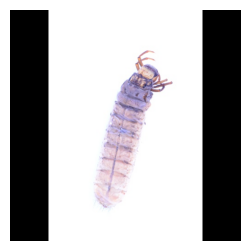

--------------------------------------------------------------------------------
🖴️ IMAGE 2 (Index: 1833) - Path: 123CRN001C.jpg
TRUE CLASS: 123


,Model,Predicted,Pred Conf,True Class Conf
0,Teacher (EfficientNet-B2),154,97.3%,1.9%
1,Student B0 — Hard Labels,154,92.0%,7.2%
2,Student B0 — Knowledge Distillation,154,78.5%,2.5%
3,Student B0 — Knowledge Distillation T10,154,79.1%,1.9%
4,Tiny CNN — Hard Labels,154,95.4%,1.7%
5,Tiny CNN — Knowledge Distillation,154,42.7%,2.4%
6,Tiny CNN — Knowledge Distillation 10,154,68.3%,2.3%
7,MobileNetV3-Small — Edge Baseline,154,79.7%,3.4%
8,MobileNetV3-Small — Knowledge Distillation,154,36.9%,10.7%
9,MobileNetV3-Small — Knowledge Distillation10,124,31.2%,2.9%


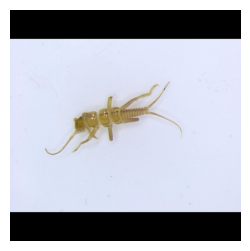

--------------------------------------------------------------------------------
🖴️ IMAGE 3 (Index: 1834) - Path: 123CRN001L.jpg
TRUE CLASS: 123


,Model,Predicted,Pred Conf,True Class Conf
0,Teacher (EfficientNet-B2),154,98.6%,0.8%
1,Student B0 — Hard Labels,154,93.6%,2.5%
2,Student B0 — Knowledge Distillation,154,56.2%,5.3%
3,Student B0 — Knowledge Distillation T10,154,52.7%,9.1%
4,Tiny CNN — Hard Labels,154,95.7%,1.8%
5,Tiny CNN — Knowledge Distillation,154,55.3%,3.8%
6,Tiny CNN — Knowledge Distillation 10,154,77.6%,2.1%
7,MobileNetV3-Small — Edge Baseline,154,52.0%,2.7%
8,MobileNetV3-Small — Knowledge Distillation,154,50.0%,5.4%
9,MobileNetV3-Small — Knowledge Distillation10,154,45.9%,1.5%


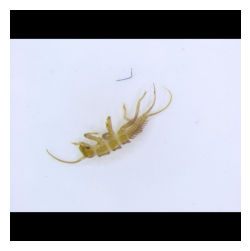

--------------------------------------------------------------------------------
🖴️ IMAGE 4 (Index: 1839) - Path: 123VIS008C.jpg
TRUE CLASS: 123


,Model,Predicted,Pred Conf,True Class Conf
0,Teacher (EfficientNet-B2),124,91.1%,6.4%
1,Student B0 — Hard Labels,124,76.4%,23.0%
2,Student B0 — Knowledge Distillation,124,55.9%,10.3%
3,Student B0 — Knowledge Distillation T10,124,62.9%,7.2%
4,Tiny CNN — Hard Labels,124,35.6%,10.4%
5,Tiny CNN — Knowledge Distillation,124,33.0%,4.4%
6,Tiny CNN — Knowledge Distillation 10,124,45.2%,4.6%
7,MobileNetV3-Small — Edge Baseline,124,88.3%,11.2%
8,MobileNetV3-Small — Knowledge Distillation,124,15.2%,12.4%
9,MobileNetV3-Small — Knowledge Distillation10,124,86.6%,3.3%


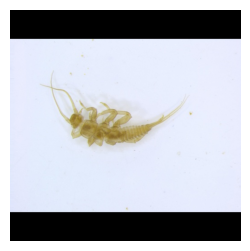

--------------------------------------------------------------------------------
🖴️ IMAGE 5 (Index: 1841) - Path: 123VIS008R.jpg
TRUE CLASS: 123


,Model,Predicted,Pred Conf,True Class Conf
0,Teacher (EfficientNet-B2),124,87.3%,12.5%
1,Student B0 — Hard Labels,124,84.2%,4.8%
2,Student B0 — Knowledge Distillation,124,67.0%,2.3%
3,Student B0 — Knowledge Distillation T10,124,58.8%,6.3%
4,Tiny CNN — Hard Labels,124,38.2%,7.7%
5,Tiny CNN — Knowledge Distillation,124,21.5%,5.5%
6,Tiny CNN — Knowledge Distillation 10,124,27.9%,5.6%
7,MobileNetV3-Small — Edge Baseline,124,89.8%,2.2%
8,MobileNetV3-Small — Knowledge Distillation,124,17.2%,13.4%
9,MobileNetV3-Small — Knowledge Distillation10,124,81.0%,2.1%


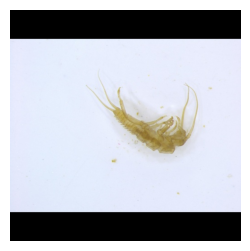

--------------------------------------------------------------------------------


In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Identification of common error indices
common_errors = sorted(list(set.intersection(*model_errors.values())))
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

print(f"Analyzing {len(common_errors)} images that no one predicted correctly...\n")

# 2. Function to extract prediction details
def get_prediction_details(model, image_tensor, true_label, img_size):
    model.eval()
    with torch.no_grad():
        img_input = F.interpolate(image_tensor.to(DEVICE), size=(img_size, img_size), mode='bilinear', align_corners=False)
        logits = model(img_input)
        probs = F.softmax(logits, dim=1)

        conf_pred, pred_idx = torch.max(probs, 1)
        conf_true = probs[0, true_label]

    return {
        'pred_class': idx_to_class[pred_idx.item()],
        'pred_conf': conf_pred.item() * 100,
        'true_conf': conf_true.item() * 100
    }

# 3. Visualization of the first 5 (or all) of those 25 images
limit = 5

for i, img_idx in enumerate(common_errors[:limit]):
    # Get image from dataset
    img_tensor, true_label = sync_test_loader.dataset[img_idx]
    img_path, _ = sync_test_loader.dataset.samples[img_idx]

    print(f"🖴️ IMAGE {i+1} (Index: {img_idx}) - Path: {Path(img_path).name}")
    print(f"TRUE CLASS: {idx_to_class[true_label]}")

    results_rows = []
    for name, model, _ in MODEL_REGISTRY:
        is_teacher = "teacher" in name.lower()
        eval_size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT

        details = get_prediction_details(model, img_tensor.unsqueeze(0), true_label, eval_size)
        results_rows.append({
            'Model': name,
            'Predicted': details['pred_class'],
            'Pred Conf': f"{details['pred_conf']:.1f}%",
            'True Class Conf': f"{details['true_conf']:.1f}%"
        })

    # Display table and image
    display(pd.DataFrame(results_rows))

    # Display image without normalization for visual check
    raw_img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(3, 3))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.show()
    print("-"*80)

Analyzing 3791 images that ALL models predicted correctly...

✅ SUCCESSFUL CLASSIFICATION 1 (Index: 604)
TRUE CLASS: 108


,Model,Status,Confidence
0,Teacher (EfficientNet-B2),CORRECT,100.00%
1,Student B0 — Hard Labels,CORRECT,97.96%
2,Student B0 — Knowledge Distillation,CORRECT,47.21%
3,Student B0 — Knowledge Distillation T10,CORRECT,75.00%
4,Tiny CNN — Hard Labels,CORRECT,91.13%
5,Tiny CNN — Knowledge Distillation,CORRECT,52.69%
6,Tiny CNN — Knowledge Distillation 10,CORRECT,86.84%
7,MobileNetV3-Small — Edge Baseline,CORRECT,98.77%
8,MobileNetV3-Small — Knowledge Distillation,CORRECT,37.46%
9,MobileNetV3-Small — Knowledge Distillation10,CORRECT,69.99%


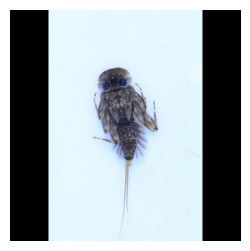

--------------------------------------------------------------------------------
✅ SUCCESSFUL CLASSIFICATION 2 (Index: 1537)
TRUE CLASS: 119


,Model,Status,Confidence
0,Teacher (EfficientNet-B2),CORRECT,100.00%
1,Student B0 — Hard Labels,CORRECT,99.08%
2,Student B0 — Knowledge Distillation,CORRECT,64.36%
3,Student B0 — Knowledge Distillation T10,CORRECT,86.53%
4,Tiny CNN — Hard Labels,CORRECT,98.51%
5,Tiny CNN — Knowledge Distillation,CORRECT,73.48%
6,Tiny CNN — Knowledge Distillation 10,CORRECT,83.10%
7,MobileNetV3-Small — Edge Baseline,CORRECT,99.99%
8,MobileNetV3-Small — Knowledge Distillation,CORRECT,77.37%
9,MobileNetV3-Small — Knowledge Distillation10,CORRECT,90.66%


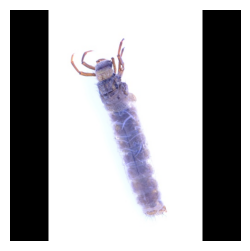

--------------------------------------------------------------------------------
✅ SUCCESSFUL CLASSIFICATION 3 (Index: 505)
TRUE CLASS: 107


,Model,Status,Confidence
0,Teacher (EfficientNet-B2),CORRECT,99.97%
1,Student B0 — Hard Labels,CORRECT,68.74%
2,Student B0 — Knowledge Distillation,CORRECT,39.46%
3,Student B0 — Knowledge Distillation T10,CORRECT,85.37%
4,Tiny CNN — Hard Labels,CORRECT,93.60%
5,Tiny CNN — Knowledge Distillation,CORRECT,64.01%
6,Tiny CNN — Knowledge Distillation 10,CORRECT,92.96%
7,MobileNetV3-Small — Edge Baseline,CORRECT,99.30%
8,MobileNetV3-Small — Knowledge Distillation,CORRECT,82.75%
9,MobileNetV3-Small — Knowledge Distillation10,CORRECT,46.70%


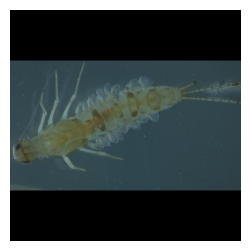

--------------------------------------------------------------------------------
✅ SUCCESSFUL CLASSIFICATION 4 (Index: 756)
TRUE CLASS: 110


,Model,Status,Confidence
0,Teacher (EfficientNet-B2),CORRECT,99.83%
1,Student B0 — Hard Labels,CORRECT,97.50%
2,Student B0 — Knowledge Distillation,CORRECT,67.95%
3,Student B0 — Knowledge Distillation T10,CORRECT,82.29%
4,Tiny CNN — Hard Labels,CORRECT,94.38%
5,Tiny CNN — Knowledge Distillation,CORRECT,66.62%
6,Tiny CNN — Knowledge Distillation 10,CORRECT,74.54%
7,MobileNetV3-Small — Edge Baseline,CORRECT,99.89%
8,MobileNetV3-Small — Knowledge Distillation,CORRECT,66.09%
9,MobileNetV3-Small — Knowledge Distillation10,CORRECT,81.16%


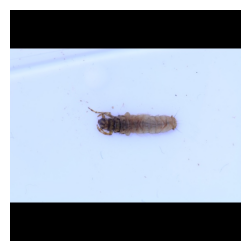

--------------------------------------------------------------------------------
✅ SUCCESSFUL CLASSIFICATION 5 (Index: 2812)
TRUE CLASS: 138


,Model,Status,Confidence
0,Teacher (EfficientNet-B2),CORRECT,99.79%
1,Student B0 — Hard Labels,CORRECT,99.99%
2,Student B0 — Knowledge Distillation,CORRECT,71.13%
3,Student B0 — Knowledge Distillation T10,CORRECT,84.23%
4,Tiny CNN — Hard Labels,CORRECT,97.11%
5,Tiny CNN — Knowledge Distillation,CORRECT,51.88%
6,Tiny CNN — Knowledge Distillation 10,CORRECT,66.73%
7,MobileNetV3-Small — Edge Baseline,CORRECT,98.86%
8,MobileNetV3-Small — Knowledge Distillation,CORRECT,71.07%
9,MobileNetV3-Small — Knowledge Distillation10,CORRECT,91.68%


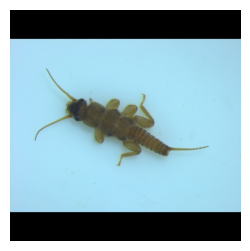

--------------------------------------------------------------------------------


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1. Identification of indices of images that ALL models predicted correctly
all_indices = set(range(len(sync_test_loader.dataset)))
all_errors_union = set().union(*model_errors.values())
correct_by_all = sorted(list(all_indices - all_errors_union))

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

print(f"Analyzing {len(correct_by_all)} images that ALL models predicted correctly...\n")

# 2. Function to extract confidence for the true class
def get_correct_prediction_details(model, image_tensor, true_label, img_size):
    model.eval()
    with torch.no_grad():
        img_input = F.interpolate(image_tensor.to(DEVICE), size=(img_size, img_size), mode='bilinear', align_corners=False)
        logits = model(img_input)
        probs = F.softmax(logits, dim=1)
        conf_true = probs[0, true_label]
    return conf_true.item() * 100

# 3. Visualization of random successful examples
limit_success = 5

# Ensure limit_success does not exceed the number of available correctly classified images
num_samples_to_show = min(limit_success, len(correct_by_all))

# Select random indices
random_successful_indices = random.sample(correct_by_all, num_samples_to_show)

for i, img_idx in enumerate(random_successful_indices):
    img_tensor, true_label = sync_test_loader.dataset[img_idx]
    img_path, _ = sync_test_loader.dataset.samples[img_idx]

    print(f"✅ SUCCESSFUL CLASSIFICATION {i+1} (Index: {img_idx})")
    print(f"TRUE CLASS: {idx_to_class[true_label]}")

    results_rows = []
    for name, model, _ in MODEL_REGISTRY:
        is_teacher = 'teacher' in name.lower()
        eval_size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT

        conf = get_correct_prediction_details(model, img_tensor.unsqueeze(0), true_label, eval_size)
        results_rows.append({
            'Model': name,
            'Status': 'CORRECT',
            'Confidence': f'{conf:.2f}%'
        })

    display(pd.DataFrame(results_rows))

    # Display image
    raw_img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(3, 3))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.show()
    print('-'*80)

## 11.2. Plots — Loss i Accuracy


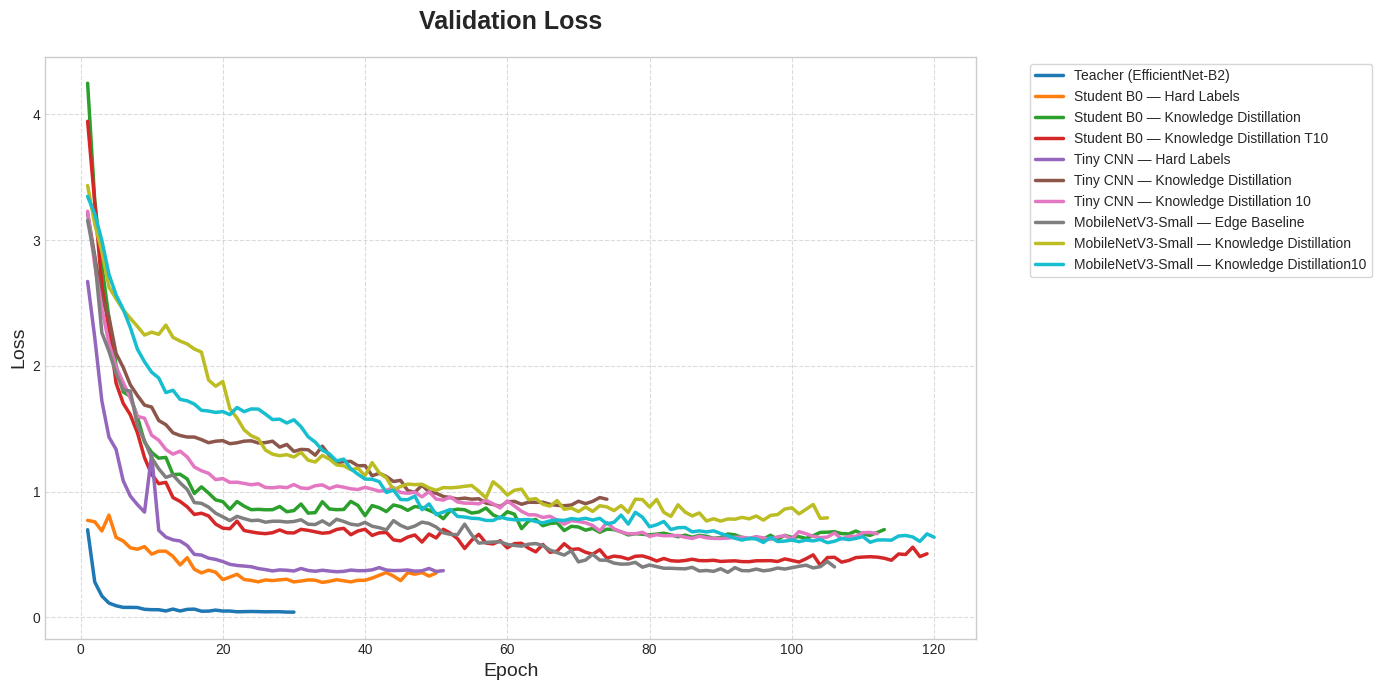

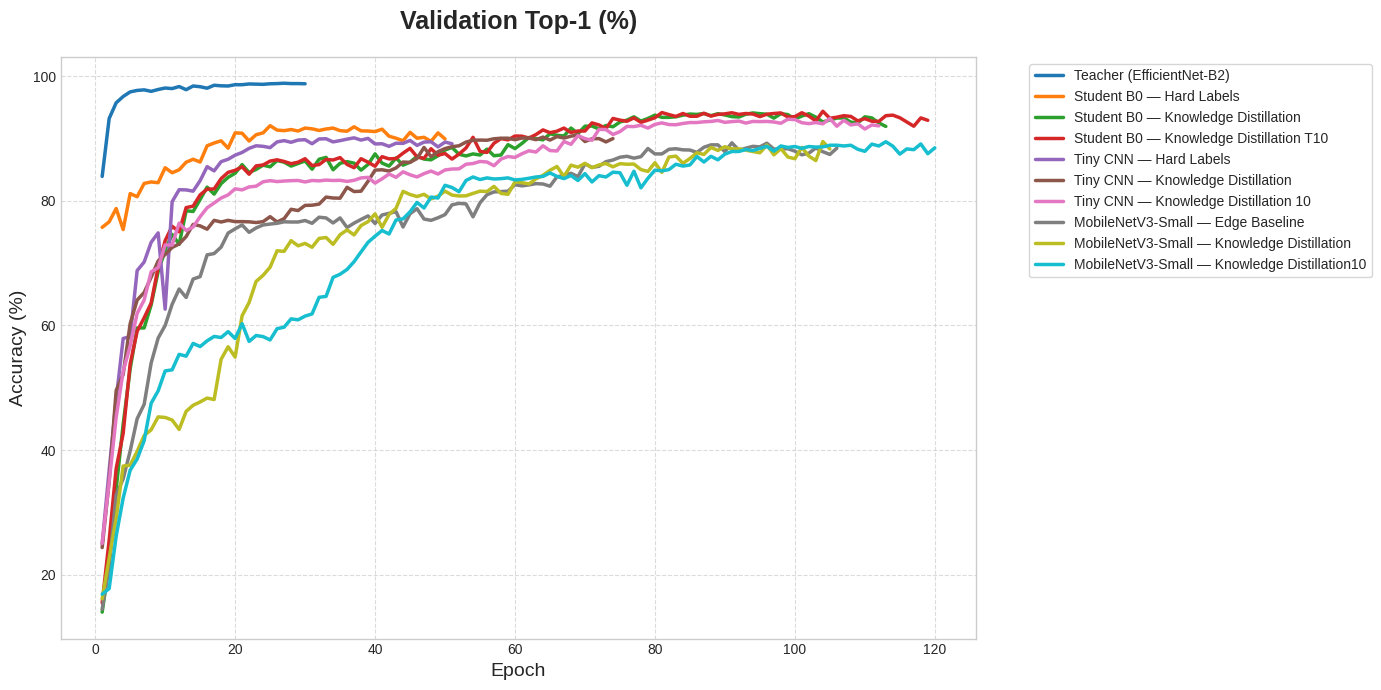

In [18]:
def load_history_only(name):
    safe = _slugify(name)
    path = RUNS_DIR / safe / 'models' / 'final_best.pt'
    if path.exists():
        return torch.load(path, map_location='cpu').get('history', {})
    return {}

plt.style.use('seaborn-v0_8-whitegrid')
metrics = [('val_loss', 'Validation Loss', 'Loss'), ('val_top1', 'Validation Top-1 (%)', 'Accuracy (%)')]
colors = plt.cm.tab10(np.linspace(0, 1, len(MODEL_REGISTRY)))

# Loop to create a separate figure for each metric
for metric_key, title, ylabel in metrics:
    plt.figure(figsize=(14, 7))

    for (name, _, _), color in zip(MODEL_REGISTRY, colors):
        hist = load_history_only(name)
        if metric_key in hist and len(hist[metric_key]) > 0:
            vals = hist[metric_key]
            epochs = list(range(1, len(vals) + 1))
            plt.plot(epochs, vals, label=name, color=color, lw=2.5)

    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 12. Grad-CAM visualization


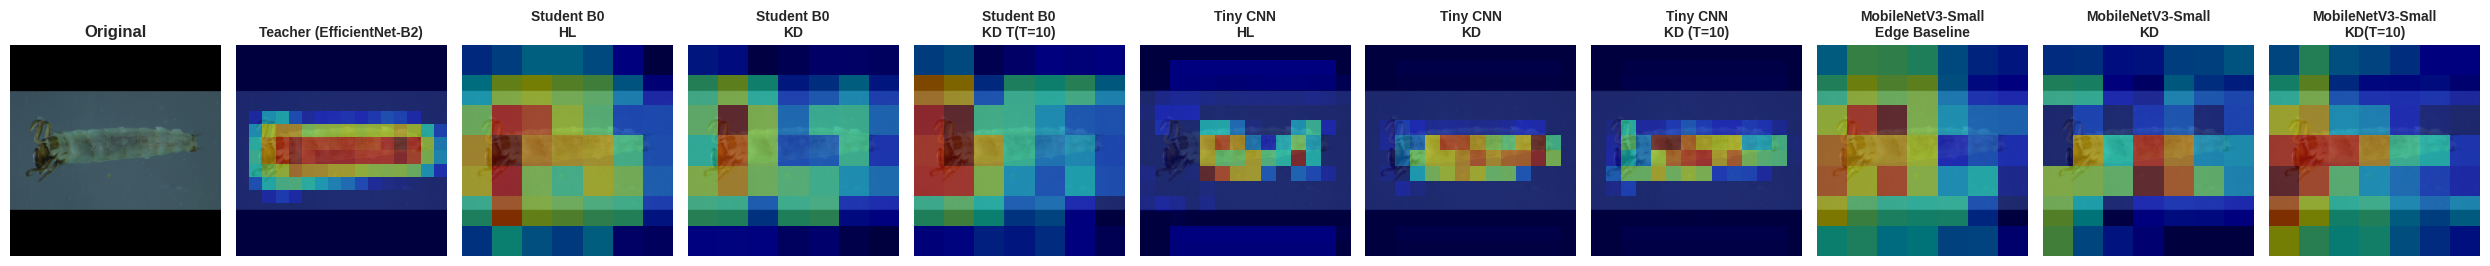

In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        self._fh = target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        self._bh = target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, x, class_idx=None):
        self.model.eval()
        x = x.clone().detach().requires_grad_(True)
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove_hooks(self):
        self._fh.remove(); self._bh.remove()

def get_target_layer(model):
    if hasattr(model, 'blocks'): return model.blocks[-1][-1]
    if hasattr(model, 'features'): return model.features[-1]
    return None

# Sample from test set
sample_idx = 10
sample_img_t, sample_label = sync_test_loader.dataset[sample_idx]
img_path, _ = sync_test_loader.dataset.samples[sample_idx]

fig, axes = plt.subplots(1, len(MODEL_REGISTRY) + 1, figsize=(25, 6))
axes[0].imshow(Image.open(img_path).convert('RGB'))
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

for i, (name, model, _) in enumerate(MODEL_REGISTRY, 1):
    tl = get_target_layer(model)
    if tl:
        gcam = GradCAM(model, tl)
        is_teacher = 'teacher' in name.lower()
        size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT
        img_in = F.interpolate(sample_img_t.unsqueeze(0).to(DEVICE), size=(size, size), mode='bilinear', align_corners=False)

        try:
            cam = gcam.generate(img_in, class_idx=sample_label)
            img_np = Image.open(img_path).convert('RGB').resize((size, size))
            axes[i].imshow(img_np)
            axes[i].imshow(cam, cmap='jet', alpha=0.5, extent=(0, size, size, 0))

            # Formatting the title to show HL/KD and Temperature
            display_name = name.replace(' — ', '\n')
            display_name = display_name.replace('Knowledge Distillation', 'KD')
            display_name = display_name.replace('Hard Labels', 'HL')
            if '10' in name or 'T10' in name:
                 display_name = display_name.replace('10', '(T=10)')

            axes[i].set_title(display_name, fontsize=10, fontweight='bold')
        except Exception as e:
            axes[i].text(0.5, 0.5, 'Error', ha='center', va='center')
        finally:
            gcam.remove_hooks()
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 13. Soft Targets visualization

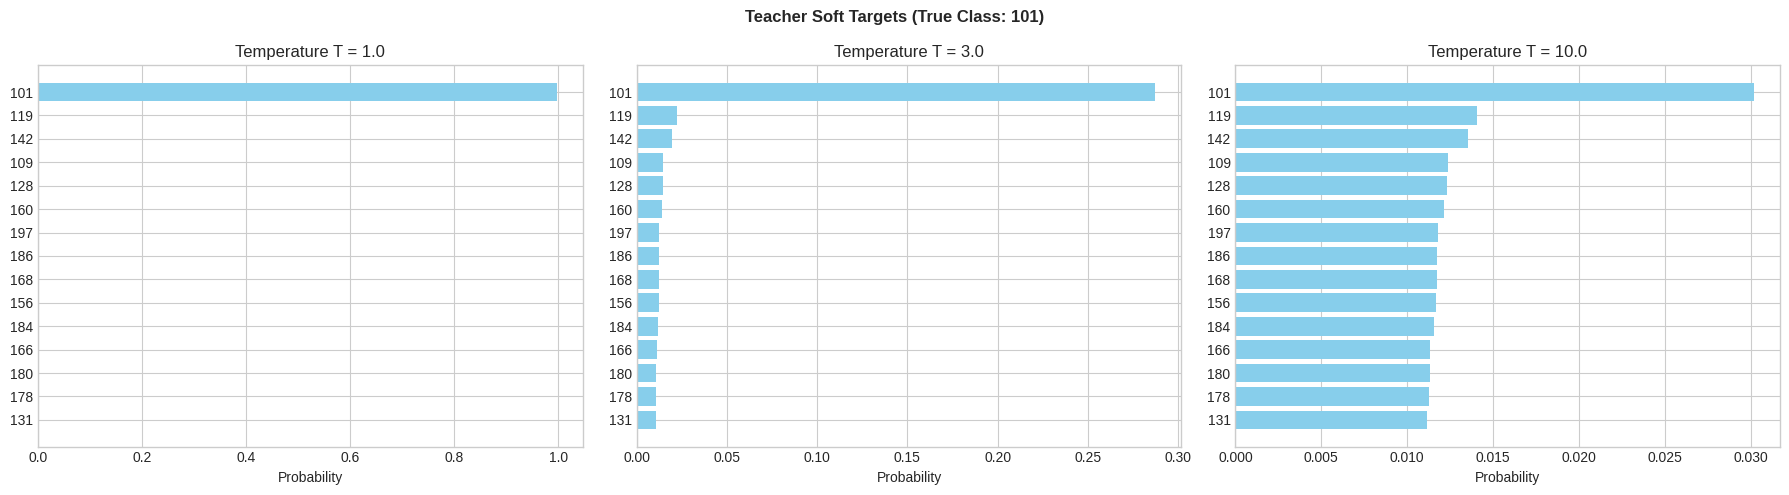

In [20]:
teacher.eval()
img_t, label_t = sync_test_loader.dataset[0]
with torch.no_grad():
    logits = teacher(img_t.unsqueeze(0).to(DEVICE))

temps = [1.0, 3.0, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Teacher Soft Targets (True Class: {idx_to_class[label_t]})', fontweight='bold')

for ax, T in zip(axes, temps):
    probs = F.softmax(logits / T, dim=1).squeeze().cpu().numpy()
    top_idx = np.argsort(probs)[-15:] # Top 15
    ax.barh([idx_to_class[i] for i in top_idx], probs[top_idx], color='skyblue')
    ax.set_title(f'Temperature T = {T}')
    ax.set_xlabel('Probability')

plt.tight_layout()
plt.show()

## 14. Analysis - Inference Latency vs. Accuracy


Measuring latencies...


,Model,Top-1 (%),GPU Latency (ms),CPU Latency (ms),Params (M)
0,Teacher (EfficientNet-B2),98.427795,12.381394,374.145792,7.841894
1,Student B0 — Hard Labels,91.013199,8.308280,36.116261,4.135648
2,Student B0 — Knowledge Distillation,93.206522,11.038508,37.871001,4.135648
3,Student B0 — Knowledge Distillation T10,93.322981,8.266258,33.190138,4.135648
4,Tiny CNN — Hard Labels,89.091615,1.016233,3.878694,0.091044
5,Tiny CNN — Knowledge Distillation,88.936335,1.134076,3.823178,0.091044
6,Tiny CNN — Knowledge Distillation 10,91.381988,1.013339,3.993804,0.091044
7,MobileNetV3-Small — Edge Baseline,87.616460,5.299416,12.963986,1.620356
8,MobileNetV3-Small — Knowledge Distillation,88.354037,7.082109,14.010763,1.620356
9,MobileNetV3-Small — Knowledge Distillation10,88.159938,7.149558,9.435546,1.620356


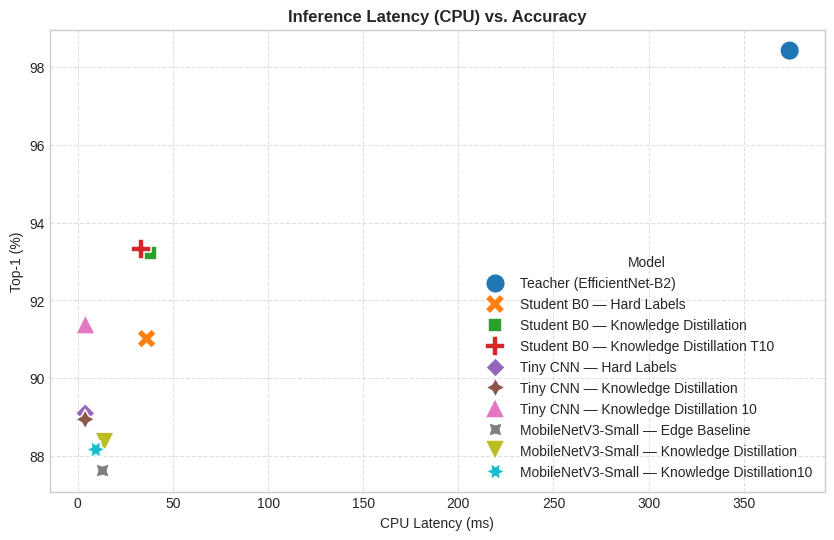

In [ ]:
import time

def measure_latency(model, img_size, device, repetitions=100):
    model.to(device)
    model.eval()
    dummy_input = torch.randn(1, 3, img_size, img_size).to(device)

    # Warm-up
    for _ in range(10):
        _ = model(dummy_input)

    # Measuring
    start_time = time.time()
    with torch.no_grad():
        for _ in range(repetitions):
            _ = model(dummy_input)
            if device.type == 'cuda':
                torch.cuda.synchronize()

    avg_latency = ((time.time() - start_time) / repetitions) * 1000 # u ms
    return avg_latency

latency_results = []

print("Measuring latencies...")
for name, model, _ in MODEL_REGISTRY:
    is_teacher = 'teacher' in name.lower()
    size = IMG_SIZE_TEACHER if is_teacher else IMG_SIZE_STUDENT

    lat_gpu = measure_latency(model, size, torch.device('cuda')) if torch.cuda.is_available() else 0
    lat_cpu = measure_latency(model, size, torch.device('cpu'))

    latency_results.append({
        'Model': name,
        'Top-1 (%)': results[name]['top1'],
        'GPU Latency (ms)': lat_gpu,
        'CPU Latency (ms)': lat_cpu,
        'Params (M)': results[name]['params_M']
    })

df_lat = pd.DataFrame(latency_results)
display(df_lat)

# Visualization (Latency vs Accuracy)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_lat, x='CPU Latency (ms)', y='Top-1 (%)', hue='Model', s=200, style='Model')
plt.title('Inference Latency (CPU) vs. Accuracy', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Additional - Check
Run this cell in order to check if the models are safely saved in Drive.

In [ ]:
import torch
import pandas as pd
import os
from pathlib import Path

def summary_saved_models(runs_dir):
    data = []
    # Looking for all final_best.pt files in subfolders
    paths = list(Path(runs_dir).rglob('final_best.pt'))

    if not paths:
        print(f'No models found in {runs_dir}')
        return

    for p in paths:
        try:
            ckpt = torch.load(p, map_location='cpu')
            name = ckpt.get('name', p.parent.parent.name)
            hist = ckpt.get('history', {})
            state_dict = ckpt.get('model_state_dict', {})

            # Parameter count and file size calculation
            num_params = sum(p.numel() for p in state_dict.values()) / 1e6
            file_size_mb = os.path.getsize(p) / (1024 * 1024)

            # Extract best values from history
            top1 = max(hist.get('val_top1', [0])) if hist.get('val_top1') else 0
            top5 = max(hist.get('val_top5', [0])) if hist.get('val_top5') else 0

            data.append({
                'Model Name': name,
                'Best Top-1 (%)': f'{top1:.2f}%',
                'Best Top-5 (%)': f'{top5:.2f}%',
                'Params (M)': f'{num_params:.2f}M',
                'Size (MB)': f'{file_size_mb:.1f} MB',
                'Epochs': len(hist.get('val_loss', [])),
                'Path': p.relative_to(runs_dir.parent)
            })
        except Exception as e:
            print(f'Error loading {p}: {e}')

    df = pd.DataFrame(data)
    if not df.empty:
        display(df.sort_values('Best Top-1 (%)', ascending=False))
    else:
        print('No valid data found in discovered files.')

summary_saved_models(RUNS_DIR)

,Model Name,Best Top-1 (%),Best Top-5 (%),Params (M),Size (MB),Epochs,Path
0,Teacher (EfficientNet-B2),98.87%,100.00%,7.91M,30.3 MB,30,runs/teacher__efficientnet_b2/models/final_bes...
7,Student B0 — Knowledge Distillation T10,94.37%,99.23%,4.18M,16.1 MB,119,runs/student_b0___knowledge_distillation_t10/m...
2,Student B0 — Knowledge Distillation,94.11%,99.20%,4.18M,16.1 MB,113,runs/student_b0___knowledge_distillation/model...
8,Tiny CNN — Knowledge Distillation 10,93.22%,99.32%,0.09M,0.4 MB,112,runs/tiny_cnn___knowledge_distillation_10/mode...
1,Student B0 — Hard Labels,92.06%,99.56%,4.18M,16.1 MB,50,runs/student_b0___hard_labels/models/final_bes...
5,Tiny CNN — Knowledge Distillation,90.58%,98.93%,0.09M,0.4 MB,74,runs/tiny_cnn___knowledge_distillation/models/...
4,Tiny CNN — Hard Labels,90.11%,99.23%,0.09M,0.4 MB,51,runs/tiny_cnn___hard_labels/models/final_best.pt
6,MobileNetV3-Small — Knowledge Distillation,89.51%,98.90%,1.63M,6.3 MB,105,runs/mobilenetv3_small___knowledge_distillatio...
9,MobileNetV3-Small — Knowledge Distillation10,89.48%,98.82%,1.63M,6.3 MB,120,runs/mobilenetv3_small___knowledge_distillatio...
3,MobileNetV3-Small — Edge Baseline,89.31%,99.44%,1.63M,6.3 MB,106,runs/mobilenetv3_small___edge_baseline/models/...
